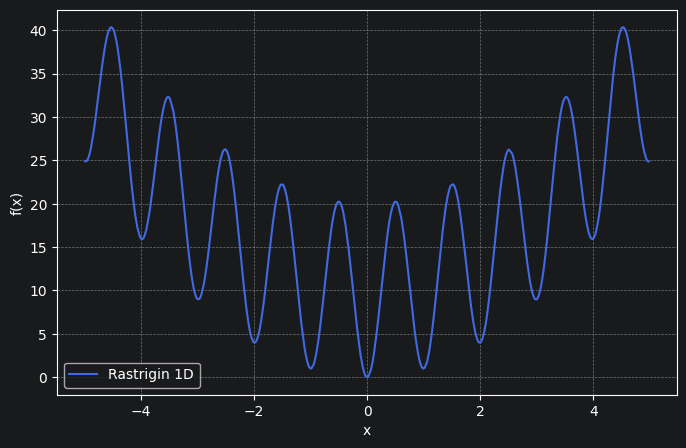

In [33]:
from matplotlib import pyplot as plt
import numpy as np
import random


MIN = -5
MAX = 5

def f_eval(x):
    # sphere function
    val_sphere = sum(xi ** 2 for xi in x)

    # Griewank function
    t1 = sum(xi ** 2 / 4000 for xi in x)
    cosine = [np.cos(xi / np.sqrt(i + 1)) for i, xi in enumerate(x)]
    t2 = np.prod(cosine, axis=0)
    val_griewank = t1 - t2 + 1

    # Rastrigin function
    val_rastrigin = 10 * len(x) + sum(xi ** 2 - 10 * np.cos(2 * np.pi * xi) for xi in x)

    return val_rastrigin

def generate_new_value():
    return np.random.uniform(MIN, MAX)

n_dim = 1
x_ref = [[generate_new_value() for _ in range(n_dim)] for _ in range(1000)]
x_ref.sort()
y_ref = [f_eval(xi) for xi in x_ref]

plt.figure(figsize=(8, 5))
plt.plot(x_ref, y_ref, label='Rastrigin 1D', color='royalblue')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

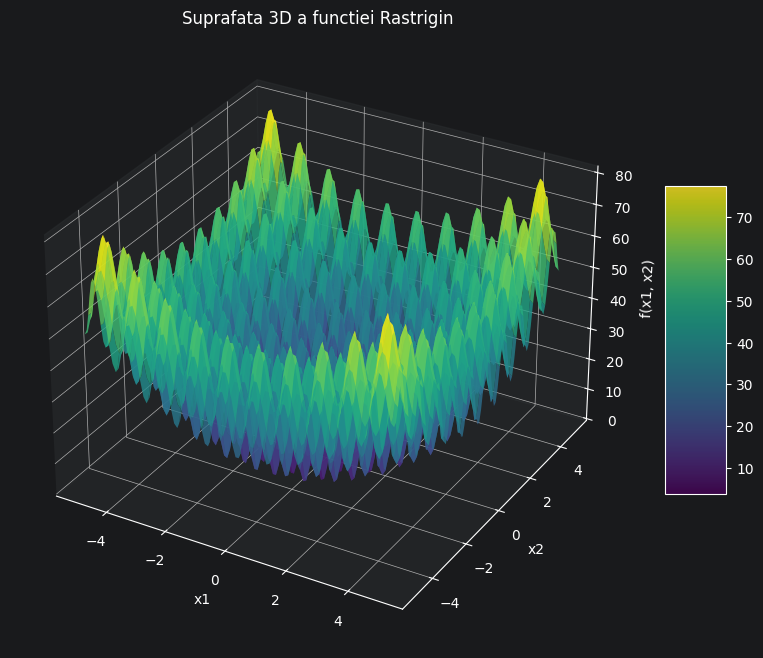

In [34]:
n_dim = 2
x_ref = [np.linspace(MIN, MAX, 100) for _ in range(n_dim)]
x1, x2 = np.meshgrid(x_ref[0], x_ref[1])
y = f_eval([x1, x2])

plt.figure(figsize=(10, 8))
ax = plt.axes(projection='3d')
surf = ax.plot_surface(x1, x2, y, cmap='viridis', edgecolor='none', alpha=0.8)
ax.set_title('Suprafata 3D a functiei Rastrigin')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('f(x1, x2)')
plt.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
plt.show()

In [35]:
class GA:
    def __init__(self, f_eval, n_dim, min_val, max_val, pop_size=100, generations=100,
                 crossover_rate=0.8, mutation_rate=0.15, tournament_size=3, elitism_size=2):
        self.f_eval = f_eval
        self.n_dim = n_dim
        self.min_val = min_val
        self.max_val = max_val
        self.pop_size = pop_size
        self.generations = generations
        self.crossover_rate = crossover_rate
        self.mutation_rate = mutation_rate
        self.tournament_size = tournament_size
        self.elitism_size = elitism_size
        self.population = []

    def init_population(self):
        self.population = [
            [random.uniform(self.min_val, self.max_val) for _ in range(self.n_dim)]
            for _ in range(self.pop_size)
        ]

    def evaluate_fitness(self, ind):
        # Se vor alege indivizii cu fitness maxim
        # Deoarece dorim minimizare, definim fitness ca fiind negativul valorii functiei
        return -self.f_eval(ind)

    def selection(self, fitnesses):
        selected_idx = random.sample(range(self.pop_size), self.tournament_size)
        best_idx = max(selected_idx, key=lambda idx: fitnesses[idx])
        return self.population[best_idx]

    def crossover(self, p1, p2):
        if random.random() > self.crossover_rate:
            return p1.copy(), p2.copy()
        # Blend Crossover (aritmetic)
        alpha = random.random()
        c1 = [alpha * x + (1.0 - alpha) * y for x, y in zip(p1, p2)]
        c2 = [(1.0 - alpha) * x + alpha * y for x, y in zip(p1, p2)]
        return c1, c2

    def mutation(self, ind):
        mutated = ind.copy()
        for i in range(self.n_dim):
            if random.random() < self.mutation_rate:
                # Mutatie gaussiana
                noise = np.random.normal(0, (self.max_val - self.min_val) * 0.1)
                mutated[i] = np.clip(mutated[i] + noise, self.min_val, self.max_val)
        return mutated

    def run(self):
        self.init_population()
        fitnesses = [self.evaluate_fitness(ind) for ind in self.population]
        best_history = []
        
        for gen in range(self.generations):
            sorted_idx = np.argsort(fitnesses)[::-1]
            self.population = [self.population[idx] for idx in sorted_idx]
            fitnesses = [fitnesses[idx] for idx in sorted_idx]
            
            best_fit: float = fitnesses[0]
            best_history.append(-best_fit)
            
            next_pop = [self.population[i].copy() for i in range(self.elitism_size)]
            while len(next_pop) < self.pop_size:
                p1 = self.selection(fitnesses)
                p2 = self.selection(fitnesses)
                c1, c2 = self.crossover(p1, p2)
                c1 = self.mutation(c1)
                c2 = self.mutation(c2)
                next_pop.append(c1)
                if len(next_pop) < self.pop_size:
                    next_pop.append(c2)
            self.population = next_pop
            fitnesses = [self.evaluate_fitness(ind) for ind in self.population]
            
        sorted_idx = np.argsort(fitnesses)[::-1]
        return self.population[sorted_idx[0]], -fitnesses[sorted_idx[0]], best_history

Dupa 150 s-a obtinut minimul 0.0016363819841842542 pentru individul format din punctele [np.float64(0.00030516474435755305), np.float64(-0.0015755915548274087), np.float64(-0.0007467847768777315), np.float64(-0.002255231073671454), np.float64(0.00017017321406027496)]


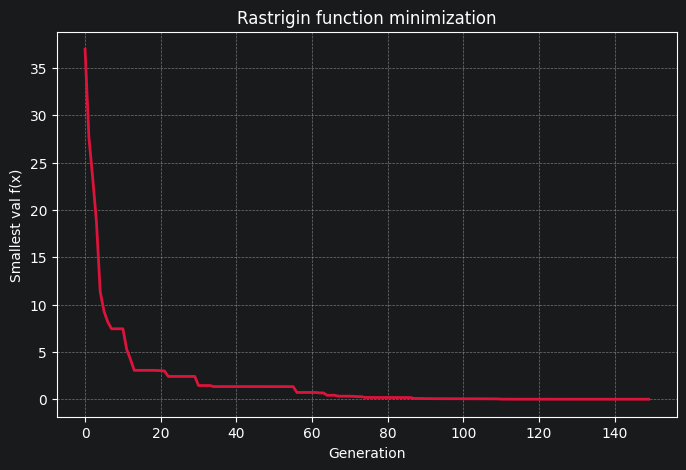

In [36]:
# Minimizare functie Rastrigin (n_dim = 5)
no_generations = 150
ga = GA(f_eval=f_eval, n_dim=5, min_val=MIN, max_val=MAX, pop_size=100, generations=no_generations)
best_sol, best_val, history = ga.run()
print(f"Dupa {no_generations} s-a obtinut minimul {best_val.item()} pentru individul format din punctele {best_sol}")

plt.figure(figsize=(8, 5))
plt.plot(history, color='crimson', linewidth=2)
plt.title('Rastrigin function minimization')
plt.xlabel('Generation')
plt.ylabel('Smallest val f(x)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [37]:
import networkx as nx
import os
import time
import numpy as np

def draw_network_comms(G, communities, title):

    node_to_comm = {}
    for c_idx, c in enumerate(communities):
        for node in c:
            node_to_comm[node] = c_idx
            
    if len(G) < 20:
        pos = nx.circular_layout(G)
    else:
        pos = nx.spring_layout(G)
        
    plt.figure(figsize=(8, 6))
    
    num_colors = len(communities)
    cmap = plt.cm.get_cmap('tab20', num_colors) if num_colors <= 20 else plt.cm.get_cmap('rainbow', num_colors)
    node_colors = [cmap(node_to_comm[node]) for node in G.nodes()]
    
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=150)
    nx.draw_networkx_edges(G, pos)
    
    if len(G) < 80:
        nx.draw_networkx_labels(G, pos, font_size=7, font_color="black", font_weight="bold")
        
    plt.title(title)
    plt.axis("off")
    plt.show()


In [ ]:
def load_gml_robust(filepath):
    G = nx.Graph()
    with open(filepath, 'r') as f:
        lines = f.readlines()

    current_node = None
    current_edge = None
    in_node = False
    in_edge = False

    for line in lines:
        line_s = line.strip()
        if line_s.startswith('node'):
            in_node = True
            current_node = {}
        elif line_s.startswith('edge'):
            in_edge = True
            current_edge = {}
        elif line_s == ']':
            if in_node:
                node_id = current_node.get('id')
                if node_id is not None:
                    label = current_node.get('label', str(node_id))
                    G.add_node(node_id, label=label, **{k: v for k, v in current_node.items() if k not in ['id', 'label']})
                in_node = False
            elif in_edge:
                u = current_edge.get('source')
                v = current_edge.get('target')
                if u is not None and v is not None:
                    G.add_edge(u, v)
                in_edge = False
        elif in_node:
            parts = line_s.split(None, 1)
            if len(parts) == 2:
                key, val = parts[0], parts[1]
                if key == 'id':
                    current_node['id'] = int(val)
                elif key == 'label':
                    current_node['label'] = val.strip('\"')
                else:
                    try:
                        current_node[key] = int(val)
                    except ValueError:
                        try:
                            current_node[key] = float(val)
                        except ValueError:
                            current_node[key] = val.strip('\"')
        elif in_edge:
            parts = line_s.split(None, 1)
            if len(parts) == 2:
                key, val = parts[0], parts[1]
                if key == 'source':
                    current_edge['source'] = int(val)
                elif key == 'target':
                    current_edge['target'] = int(val)
                else:
                    try:
                        current_edge[key] = int(val)
                    except ValueError:
                        try:
                            current_edge[key] = float(val)
                        except ValueError:
                            current_edge[key] = val.strip('\"')
    return G

In [39]:
class Chromosome:
    def __init__(self, problParam=None):
        self.__problParam = problParam
        self.__repres = []
        self.__fitness = 0.0
        self.initialisation()

    @property
    def repres(self):
        return self.__repres

    @property
    def fitness(self):
        return self.__fitness

    @fitness.setter
    def fitness(self, val):
        self.__fitness = val

    def initialisation(self):
        n = self.__problParam['noNodes']
        neighbors = self.__problParam['neighbors_idx']
        for i in range(n):
            if neighbors[i]:
                self.__repres.append(random.choice(neighbors[i]))
            else:
                self.__repres.append(i)

    def crossover(self, other):
        n = self.__problParam['noNodes']
        child = Chromosome(self.__problParam)
        child_repres = []
        for i in range(n):
            if random.random() < 0.5:
                child_repres.append(self.__repres[i])
            else:
                child_repres.append(other.__repres[i])
        child.__repres = child_repres
        return child

    def mutation(self):
        n = self.__problParam['noNodes']
        neighbors = self.__problParam['neighbors_idx']
        pm = self.__problParam.get('pm', 0.1)
        for i in range(n):
            if random.random() < pm:
                if len(neighbors[i]) > 1:
                    choices = [x for x in neighbors[i] if x != self.__repres[i]]
                    if choices:
                        self.__repres[i] = random.choice(choices)
                elif len(neighbors[i]) == 1:
                    self.__repres[i] = neighbors[i][0]

In [40]:
class GA:
    def __init__(self, param=None, problParam=None):
        self.__param = param
        self.__problParam = problParam
        self.__population = []

    @property
    def population(self):
        return self.__population

    def initialisation(self):
        self.__population = []
        for _ in range(self.__param['popSize']):
            self.__population.append(Chromosome(self.__problParam))

    def evaluation(self):
        for c in self.__population:
            c.fitness = self.__problParam['function'](c.repres, self.__problParam)

    def bestChromosome(self):
        best = self.__population[0]
        for c in self.__population:
            if c.fitness > best.fitness:
                best = c
        return best

    def worstChromosome(self):
        worst = self.__population[0]
        for c in self.__population:
            if c.fitness < worst.fitness:
                worst = c
        return worst

    def selection(self):
        pos1 = random.randint(0, self.__param['popSize'] - 1)
        pos2 = random.randint(0, self.__param['popSize'] - 1)
        if self.__population[pos1].fitness > self.__population[pos2].fitness:
            return pos1
        else:
            return pos2

    def oneGeneration(self):
        newPop = []
        for _ in range(self.__param['popSize']):
            p1 = self.__population[self.selection()]
            p2 = self.__population[self.selection()]
            off = p1.crossover(p2)
            off.mutation()
            newPop.append(off)
        self.__population = newPop
        self.evaluation()

    def oneGenerationElitism(self):
        newPop = [self.bestChromosome()]
        for _ in range(self.__param['popSize'] - 1):
            p1 = self.__population[self.selection()]
            p2 = self.__population[self.selection()]
            off = p1.crossover(p2)
            off.mutation()
            newPop.append(off)
        self.__population = newPop
        self.evaluation()

In [42]:
def decode(repres, problParam):
    G_dec = nx.Graph()
    G_dec.add_nodes_from(range(problParam['noNodes']))
    for i, gene in enumerate(repres):
        G_dec.add_edge(i, gene)

    components = list(nx.connected_components(G_dec))
    idx_to_node = problParam['idx_to_node']
    return [set(idx_to_node[idx] for idx in comp) for comp in components]

def fitness_modularity(repres, problParam):
    comms = decode(repres, problParam)
    return nx.community.modularity(problParam['graph'], comms)

def fitness_community_fitness(repres, problParam):
    comms = decode(repres, problParam)
    fit = 0.0
    G = problParam['graph']
    for c in comms:
        l_in = G.subgraph(c).number_of_edges()
        l_out = nx.cut_size(G, c)
        denom = 2 * l_in + l_out
        if denom > 0:
            fit += (2 * l_in) / denom
    return fit

def fitness_ncut(repres, problParam):
    comms = decode(repres, problParam)
    ncut_val = 0.0
    G = problParam['graph']
    for c in comms:
        l_out = nx.cut_size(G, c)
        vol = sum(G.degree(n) for n in c)
        if vol > 0:
            ncut_val += l_out / vol
    return -ncut_val

In [38]:
def run_predefined_algorithms(G, name):
    results = {}

    # 1. Louvain
    t0 = time.time()
    try:
        louvain_comms = list(nx.community.louvain_communities(G))
        louvain_time = time.time() - t0
        louvain_mod = nx.community.modularity(G, louvain_comms)
        results['Louvain'] = {
            'num_comms': len(louvain_comms),
            'modularity': louvain_mod,
            'time': louvain_time,
            'comms': louvain_comms
        }
    except Exception as e:
        print(f"Louvain failed for {name}: {e}")

    # 2. Greedy Modularity
    t0 = time.time()
    try:
        greedy_comms = list(nx.community.greedy_modularity_communities(G))
        greedy_time = time.time() - t0
        greedy_mod = nx.community.modularity(G, greedy_comms)
        results['Greedy'] = {
            'num_comms': len(greedy_comms),
            'modularity': greedy_mod,
            'time': greedy_time,
            'comms': greedy_comms
        }
    except Exception as e:
        print(f"Greedy failed for {name}: {e}")

    return results

base_dir = './real'
networks = ['karate', 'dolphins', 'football', 'krebs']
predef_results = {}

for net in networks:
    path = os.path.join(base_dir, net, f'{net}.gml')
    G = load_gml_robust(path)
    print(f"\nNetwork {net.capitalize()} ({len(G.nodes())} nodes, {len(G.edges())} edges)")
    res = run_predefined_algorithms(G, net)
    predef_results[net] = res
    for alg, metrics in res.items():
        print(f"  [{alg}] Comms: {metrics['num_comms']}, Modularity: {metrics['modularity']:.4f}, Time: {metrics['time']:.4f}s")


Network Karate (34 nodes, 78 edges)
  [Louvain] Comms: 4, Modularity: 0.4198, Time: 0.0011s
  [Greedy] Comms: 3, Modularity: 0.3807, Time: 0.0018s

Network Dolphins (62 nodes, 159 edges)
  [Louvain] Comms: 5, Modularity: 0.5188, Time: 0.0014s
  [Greedy] Comms: 4, Modularity: 0.4955, Time: 0.0039s

Network Football (115 nodes, 613 edges)
  [Louvain] Comms: 10, Modularity: 0.6043, Time: 0.0031s
  [Greedy] Comms: 6, Modularity: 0.5497, Time: 0.0169s

Network Krebs (105 nodes, 441 edges)
  [Louvain] Comms: 4, Modularity: 0.5267, Time: 0.0032s
  [Greedy] Comms: 4, Modularity: 0.5020, Time: 0.0128s



GA run on Karate

  [GA - modularity] Comms: 4, Modularity: 0.4198, Time: 0.44s


/var/folders/kj/v0vprfn10c18p_nj2zhmzmx80000gn/T/ipykernel_56399/3296636713.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', num_colors) if num_colors <= 20 else plt.cm.get_cmap('rainbow', num_colors)


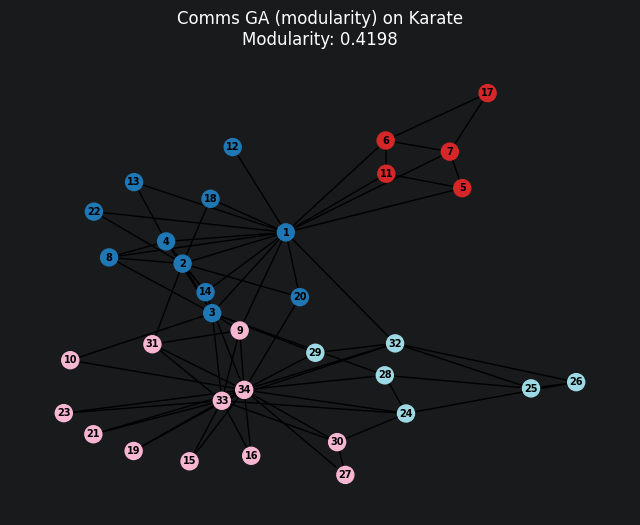

  [GA - community_fitness] Comms: 10, Modularity: 0.2750, Time: 0.97s


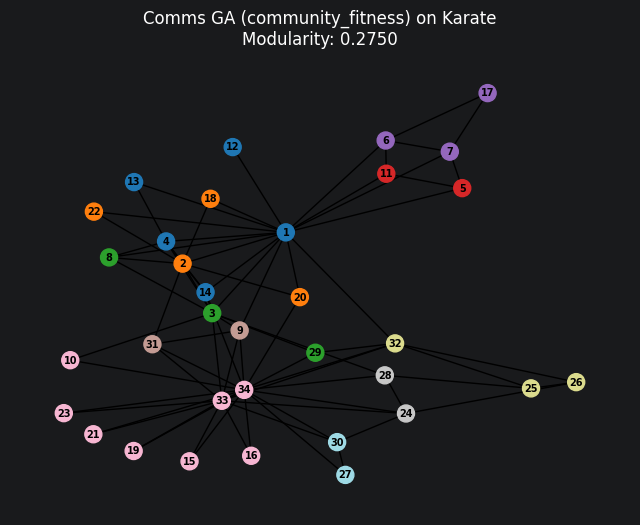

  [GA - ncut] Comms: 1, Modularity: 0.0000, Time: 0.39s


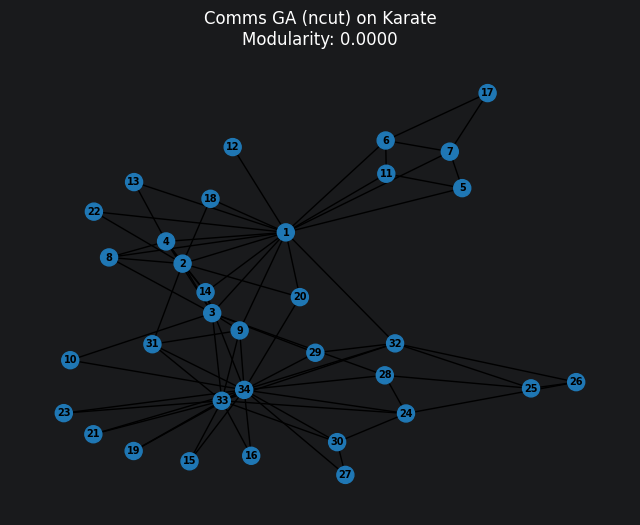


GA run on Dolphins

  [GA - modularity] Comms: 4, Modularity: 0.5175, Time: 0.80s


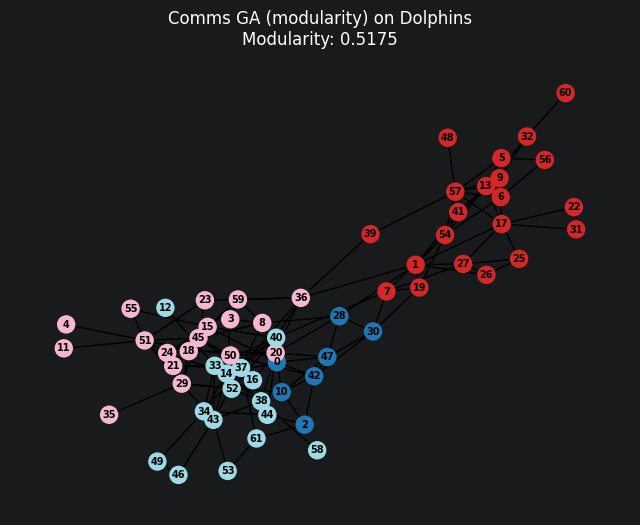

  [GA - community_fitness] Comms: 17, Modularity: 0.2923, Time: 1.76s


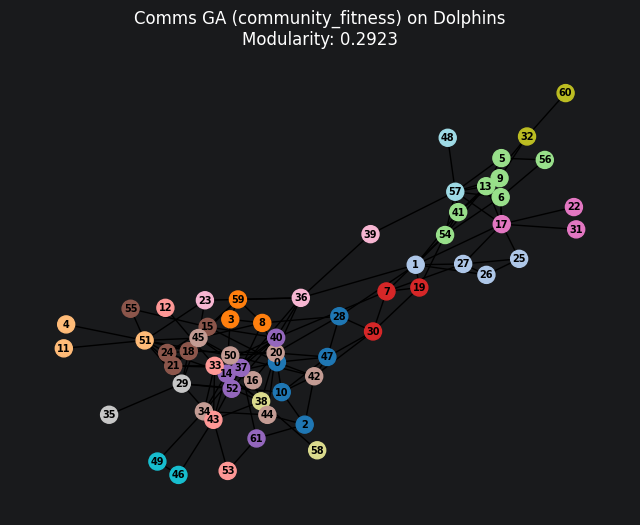

  [GA - ncut] Comms: 1, Modularity: 0.0000, Time: 0.76s


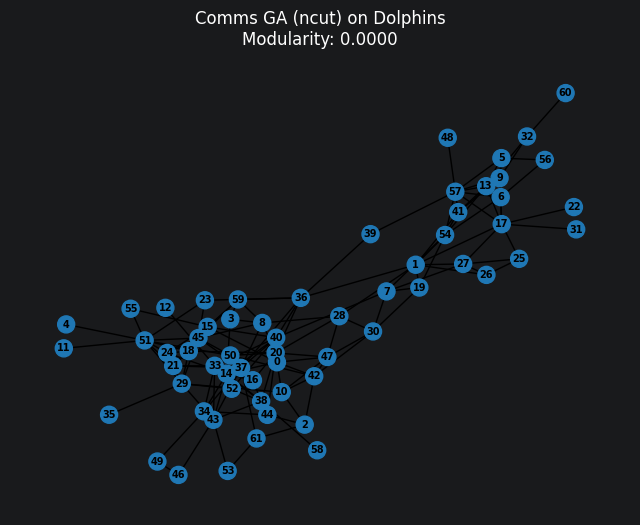


GA run on Football

  [GA - modularity] Comms: 8, Modularity: 0.5001, Time: 1.85s


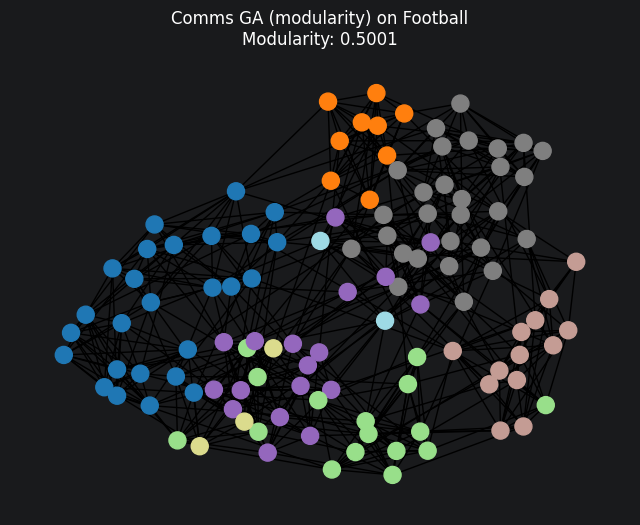

  [GA - community_fitness] Comms: 13, Modularity: 0.4828, Time: 3.76s


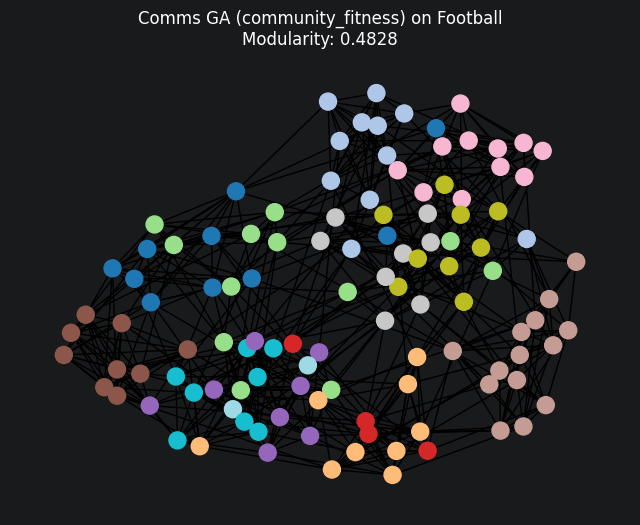

  [GA - ncut] Comms: 1, Modularity: 0.0000, Time: 1.75s


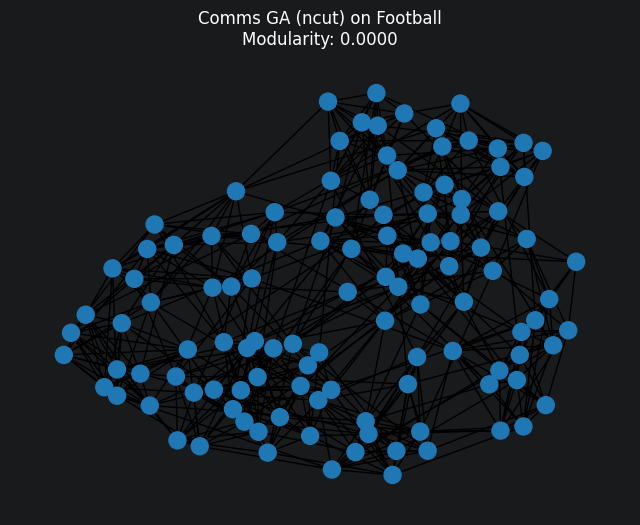


GA run on Krebs

  [GA - modularity] Comms: 4, Modularity: 0.5044, Time: 1.48s


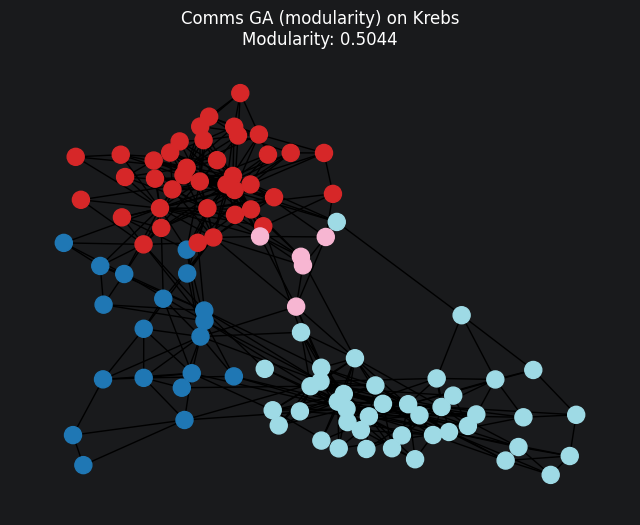

  [GA - community_fitness] Comms: 19, Modularity: 0.2671, Time: 3.16s


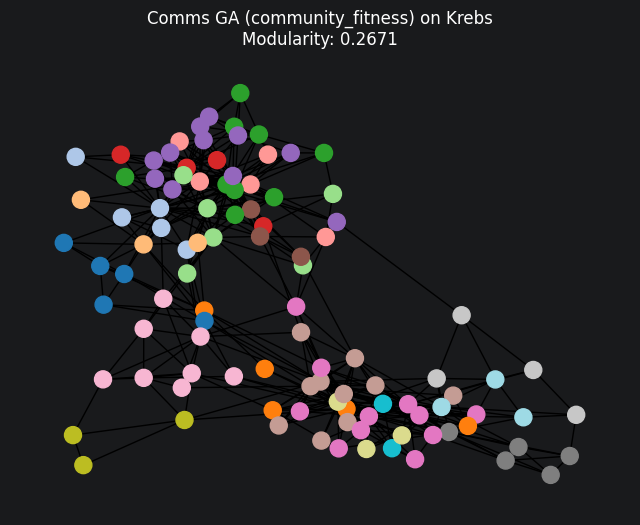

  [GA - ncut] Comms: 1, Modularity: 0.0000, Time: 1.42s


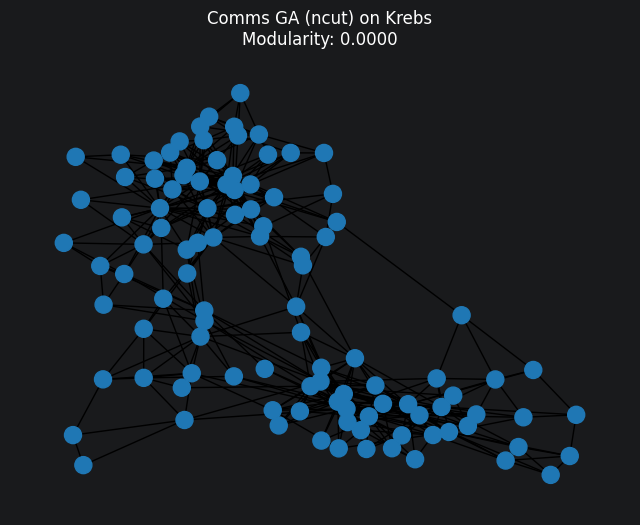

In [44]:
custom_ga_results = {}

for net in networks:
    path = os.path.join(base_dir, net, f'{net}.gml')
    G = load_gml_robust(path)
    custom_ga_results[net] = {}
    
    nodes = list(G.nodes())
    N = len(nodes)
    node_to_idx = {node: i for i, node in enumerate(nodes)}
    idx_to_node = {i: node for i, node in enumerate(nodes)}
    
    neighbors_idx = {}
    for u in nodes:
        u_idx = node_to_idx[u]
        neighbors = list(G.neighbors(u))
        neighbors_idx[u_idx] = [node_to_idx[v] for v in neighbors]
        
    print(f"\nGA run on {net.capitalize()}\n")
    for fit_type in ['modularity', 'community_fitness', 'ncut']:
        t0 = time.time()
        
        fit_func = fitness_modularity if fit_type == 'modularity' else fitness_community_fitness if fit_type == 'community_fitness' else fitness_ncut
        
        gaParam = {'popSize': 60, 'noGen': 80}
        problParam = {
            'noNodes': N,
            'graph': G,
            'node_to_idx': node_to_idx,
            'idx_to_node': idx_to_node,
            'neighbors_idx': neighbors_idx,
            'function': fit_func,
            'pm': 0.1,
            'pc': 0.8
        }
        
        ga = GA(gaParam, problParam)
        ga.initialisation()
        ga.evaluation()
        
        history = []
        for gen in range(gaParam['noGen']):
            ga.oneGenerationElitism()
            best = ga.bestChromosome()
            history.append(best.fitness)
            
        run_time = time.time() - t0
        best_chromo = ga.bestChromosome()
        best_comms = decode(best_chromo.repres, problParam)
        mod_score = nx.community.modularity(G, best_comms)
        
        print(f"  [GA - {fit_type}] Comms: {len(best_comms)}, Modularity: {mod_score:.4f}, Time: {run_time:.2f}s")
        custom_ga_results[net][fit_type] = {
            'num_comms': len(best_comms),
            'modularity': mod_score,
            'time': run_time,
            'comms': best_comms,
            'history': history
        }
        
        draw_network_comms(G, best_comms, f"Comms GA ({fit_type}) on {net.capitalize()}\nModularity: {mod_score:.4f}")


Network Florentine Families (15 nodes, 20 edges)
  [Louvain] Comms: 4, Modularity: 0.3975, Time: 0.0010s
  [GA-Mod]  Comms: 3, Modularity: 0.3987, Time: 0.1661s


/var/folders/kj/v0vprfn10c18p_nj2zhmzmx80000gn/T/ipykernel_56399/3296636713.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', num_colors) if num_colors <= 20 else plt.cm.get_cmap('rainbow', num_colors)


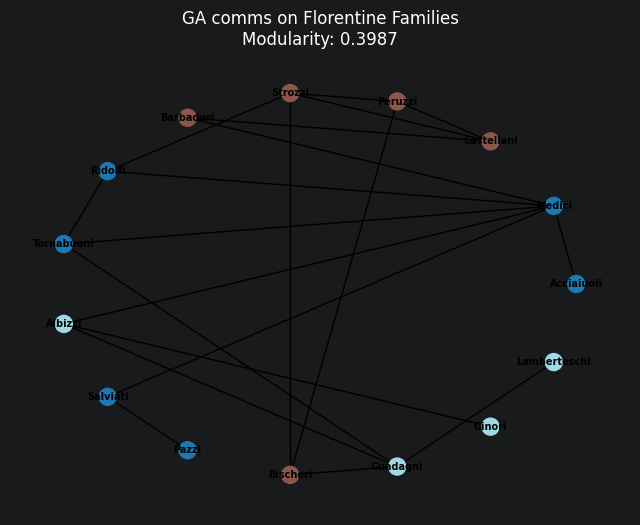


Network Les Miserables (77 nodes, 254 edges)
  [Louvain] Comms: 5, Modularity: 0.5593, Time: 0.0017s
  [GA-Mod]  Comms: 7, Modularity: 0.5649, Time: 0.8375s


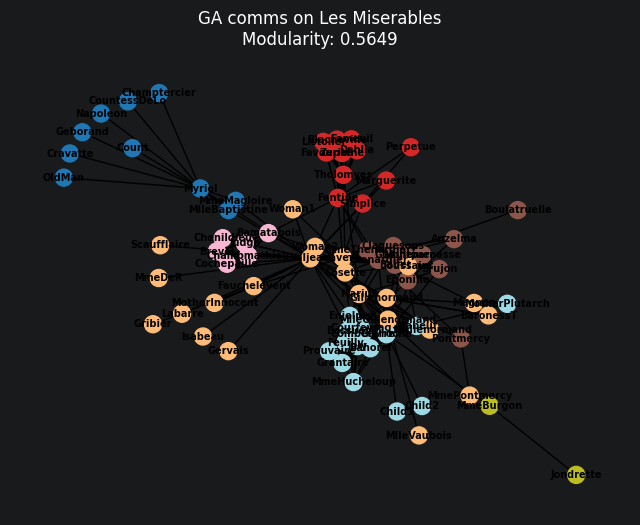


Network Caveman 5x5 (25 nodes, 50 edges)
  [Louvain] Comms: 5, Modularity: 0.7000, Time: 0.0005s
  [GA-Mod]  Comms: 5, Modularity: 0.7000, Time: 0.2842s


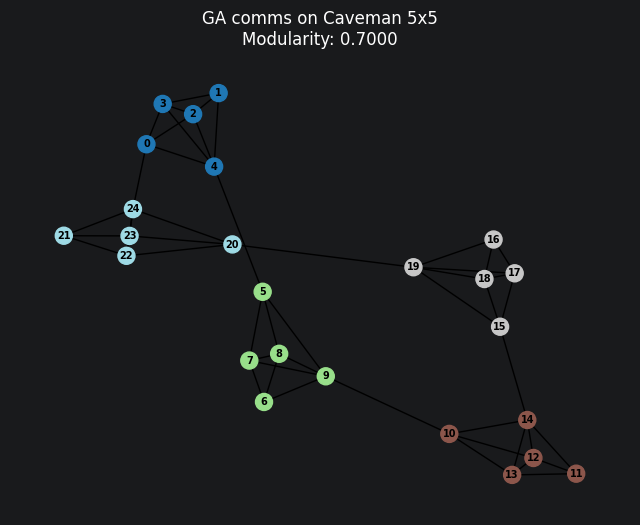


Network Caveman 6x6 (36 nodes, 90 edges)
  [Louvain] Comms: 6, Modularity: 0.7667, Time: 0.0006s
  [GA-Mod]  Comms: 6, Modularity: 0.7667, Time: 0.3727s


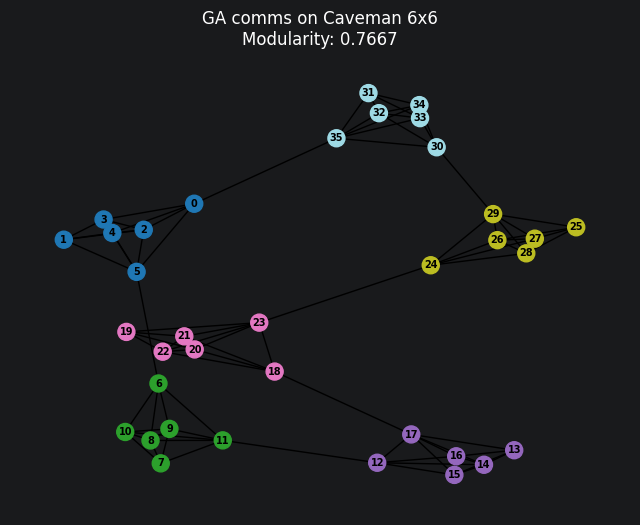


Network SBM 3-partition (60 nodes, 363 edges)
  [Louvain] Comms: 3, Modularity: 0.4706, Time: 0.0016s
  [GA-Mod]  Comms: 3, Modularity: 0.4655, Time: 0.7549s


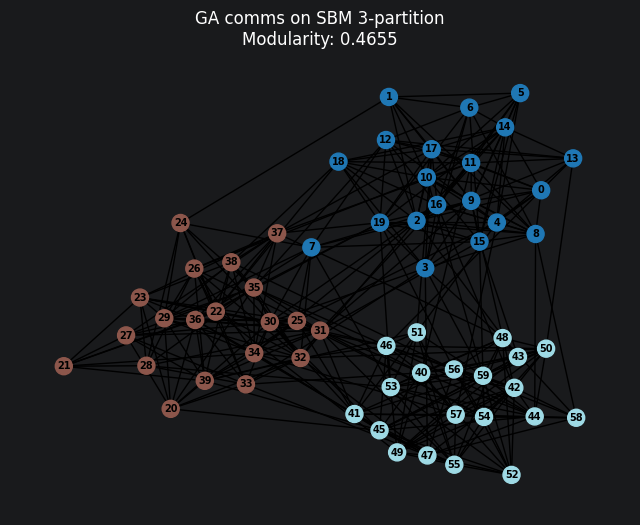


Network SBM 4-partition (60 nodes, 294 edges)
  [Louvain] Comms: 4, Modularity: 0.5956, Time: 0.0017s
  [GA-Mod]  Comms: 4, Modularity: 0.5956, Time: 0.6927s


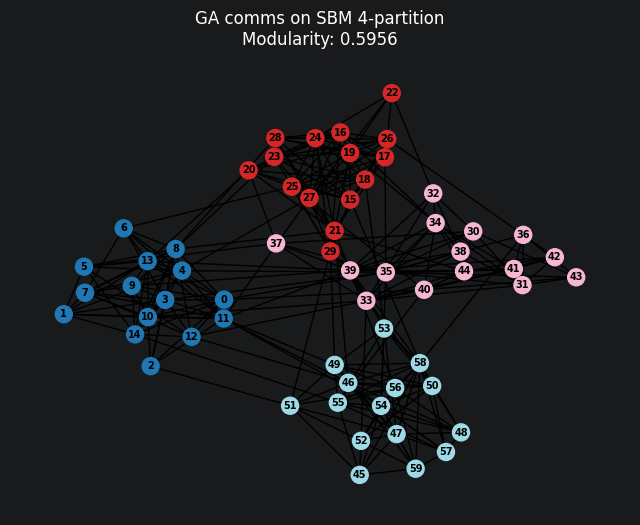

In [45]:
other_networks = {
    'Florentine Families': nx.florentine_families_graph(),
    'Les Miserables': nx.les_miserables_graph(),
    'Caveman 5x5': nx.connected_caveman_graph(5, 5),
    'Caveman 6x6': nx.connected_caveman_graph(6, 6),
    'SBM 3-partition': nx.random_partition_graph([20, 20, 20], 0.5, 0.05, seed=42),
    'SBM 4-partition': nx.random_partition_graph([15, 15, 15, 15], 0.6, 0.03, seed=42)
}

student_results = {}
for name, G in other_networks.items():
    print(f"\nNetwork {name} ({len(G.nodes())} nodes, {len(G.edges())} edges)")
    
    # Run Louvain
    t0 = time.time()
    louvain_comms = list(nx.community.louvain_communities(G))
    louvain_time = time.time() - t0
    louvain_mod = nx.community.modularity(G, louvain_comms)
    print(f"  [Louvain] Comms: {len(louvain_comms)}, Modularity: {louvain_mod:.4f}, Time: {louvain_time:.4f}s")
    
    # Run Custom GA with modularity
    t0 = time.time()
    nodes = list(G.nodes())
    N = len(nodes)
    node_to_idx = {node: i for i, node in enumerate(nodes)}
    idx_to_node = {i: node for i, node in enumerate(nodes)}
    
    neighbors_idx = {}
    for u in nodes:
        u_idx = node_to_idx[u]
        neighbors = list(G.neighbors(u))
        neighbors_idx[u_idx] = [node_to_idx[v] for v in neighbors]
        
    gaParam = {'popSize': 60, 'noGen': 60}
    problParam = {
        'noNodes': N,
        'graph': G,
        'node_to_idx': node_to_idx,
        'idx_to_node': idx_to_node,
        'neighbors_idx': neighbors_idx,
        'function': fitness_modularity,
        'pm': 0.1,
        'pc': 0.8
    }
    
    ga = GA(gaParam, problParam)
    ga.initialisation()
    ga.evaluation()
    
    for gen in range(gaParam['noGen']):
        ga.oneGenerationElitism()
        
    ga_time = time.time() - t0
    best_chromo = ga.bestChromosome()
    best_comms = decode(best_chromo.repres, problParam)
    ga_mod = nx.community.modularity(G, best_comms)
    print(f"  [GA-Mod]  Comms: {len(best_comms)}, Modularity: {ga_mod:.4f}, Time: {ga_time:.4f}s")
    
    student_results[name] = {
        'Louvain': {'num_comms': len(louvain_comms), 'modularity': louvain_mod},
        'GA': {'num_comms': len(best_comms), 'modularity': ga_mod}
    }
    
    draw_network_comms(G, best_comms, f"GA comms on {name}\nModularity: {ga_mod:.4f}")